In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
# Colab
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# Encoding
import chardet

# remember to update path

with open("/content/drive/MyDrive/combined.csv", "rb") as f:
    raw = f.read()
    result = chardet.detect(raw)

print(result)

{'encoding': 'Windows-1252', 'confidence': 0.73, 'language': ''}


In [5]:
# Setting Columns Display
pd.set_option('display.max_columns', None)

# Load Dataset
df = pd.read_csv("/content/drive/MyDrive/combined.csv", encoding=result["encoding"])
#df.head()

# Revoming rows where all labels are 0

lab = df.iloc[:, 9:]

lab_sum = lab.sum(axis=1)
df = df[lab_sum > 0]
# Keep ONLY rows with exactly ONE label
df = df[lab_sum == 1]

# Text preprocessing
import re
import nltk
from nltk.corpus import stopwords

# Download stopwords once
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def clean_text(text):
  # Remove URLs and mentions
    text = re.sub(r"http\S+|www\S+|@\w+", "", text)

    # Lowercase the text
    text = text.lower()

    # Remove punctuation and numbers
    text = re.sub(r"[^\w\s]", "", text)
    text = re.sub(r"\d+", "", text)
    # Remove extra whitespace
    text = re.sub(r"\s+", " ", text).strip()
    # Remove stop words
    text = ' '.join([word for word in text.split() if word not in stop_words])
    return text

df['text_cleaned'] = df['text'].apply(clean_text)

emotion_labels = [
    "admiration","amusement","anger","annoyance","approval","caring","confusion",
    "curiosity","desire","disappointment","disapproval","disgust","embarrassment",
    "excitement","fear","gratitude","grief","joy","love","nervousness","optimism",
    "pride","realization","relief","remorse","sadness","surprise","neutral"
]

X = df["text_cleaned"]
y = df[emotion_labels]

/tmp/ipython-input-647564134.py:15: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df = df[lab_sum == 1]
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [6]:
X

,text_cleaned
0,game hurt
2,right dont care fuck em
3,man love reddit
4,name nowhere near falcon
5,right considering important document know damn...
...,...
211219,well im glad youre awful way act make think he...
211220,everyone likes name
211221,well youve imported gazillion country gets ser...
211222,looks amazing


In [7]:
y

,admiration,amusement,anger,annoyance,approval,caring,confusion,curiosity,desire,disappointment,disapproval,disgust,embarrassment,excitement,fear,gratitude,grief,joy,love,nervousness,optimism,pride,realization,relief,remorse,sadness,surprise,neutral
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
5,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
211219,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
211220,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0
211221,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
211222,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [8]:
# Label Mapping

# Group Assignment

Positive = [
    'admiration', 'amusement', 'approval', 'caring',
    'desire', 'excitement', 'gratitude', 'joy',
    'love', 'optimism', 'pride', 'relief'
]

Negative = [
    'anger', 'annoyance', 'disapproval', 'disappointment',
    'disgust', 'embarrassment', 'fear', 'grief',
    'nervousness', 'remorse', 'sadness'
]

Neutral = [
    'confusion', 'curiosity', 'realization', 'surprise', 'neutral'
]

In [9]:
# Mapping

def mapping(y, positive, negative, neutral):
  grouped = pd.DataFrame(0, index=y.index, columns=['Positive', 'Negative', 'Neutral'])

  grouped['Positive'] = y[positive].max(axis=1)
  grouped['Negative'] = y[negative].max(axis=1)
  grouped['Neutral'] = y[neutral].max(axis=1)

  return grouped

y_mapped = mapping(y, Positive, Negative, Neutral)
y_mapped

,Positive,Negative,Neutral
0,0,1,0
2,0,0,1
3,1,0,0
4,0,0,1
5,1,0,0
...,...,...,...
211219,1,0,0
211220,1,0,0
211221,1,0,0
211222,1,0,0


Axes(0.125,0.11;0.775x0.77)


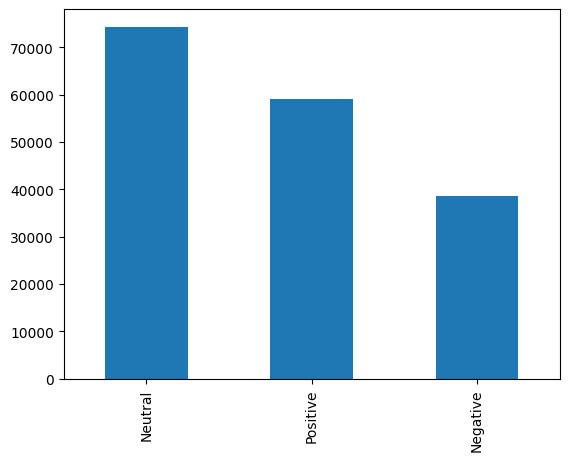

In [10]:
label_counts = y_mapped.sum().sort_values(ascending=False).plot(kind='bar')
print(label_counts)

In [11]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report, precision_score, recall_score
from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

In [12]:
# Buiding Models Pipeline and Data Spliting
#Stratify on y

X_train, X_test, y_train, y_test = train_test_split(X, y_mapped, test_size=.3, random_state=42, stratify=y_mapped)

pipeMNB = Pipeline([('tfidg', TfidfVectorizer()), ('clf', OneVsRestClassifier(MultinomialNB()))])
pipeCNB = Pipeline([('tfidg', TfidfVectorizer()), ('clf', OneVsRestClassifier(ComplementNB()))])

In [13]:
X_train = X_train.squeeze()
X_test  = X_test.squeeze()

X_train

,text_cleaned
78935,seems stupid
29187,yeah like im highkey anxious getting shocked s...
100422,know damn well theyd say narudo assault titan
39100,saw front page thing could think
177257,looks deliriously boring
...,...
63588,delusional name difference though name seems p...
165956,thats slick would love see guys
131496,name stop trying idiot
101550,great shot


In [14]:
# Training and Testing
pipeMNB.fit(X_train, y_train)
predictMNB = pipeMNB.predict(X_test)
scoreMNB = classification_report(y_test, predictMNB)

print(f"Multinomial NB's F1 Score: {f1_score(y_test, predictMNB, average='macro')*100}")
print(scoreMNB)


pipeCNB.fit(X_train, y_train)
predictCNB = pipeCNB.predict(X_test)
scoreCNB = classification_report(y_test, predictCNB)

print(f" Complement NB's F1 Score: {f1_score(y_test, predictCNB, average='macro')*100}")
print(scoreCNB)

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Multinomial NB's F1 Score: 39.50112250668054
              precision    recall  f1-score   support

           0       0.79      0.39      0.52     17690
           1       0.65      0.10      0.17     11564
           2       0.66      0.39      0.49     22292

   micro avg       0.70      0.33      0.45     51546
   macro avg       0.70      0.29      0.40     51546
weighted avg       0.70      0.33      0.43     51546
 samples avg       0.33      0.33      0.33     51546

 Complement NB's F1 Score: 58.673914373123424
              precision    recall  f1-score   support

           0       0.63      0.66      0.65     17690
           1       0.45      0.58      0.51     11564
           2       0.61      0.60      0.61     22292

   micro avg       0.57      0.62      0.60     51546
   macro avg       0.56      0.62      0.59     51546
weighted avg       0.58      0.62      0.60     51546
 samples avg       0.54      0.62      0.57     51546



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [15]:
print(f" Accuracy MNB: {accuracy_score(y_test, predictMNB)*100}")
print(f" Accuracy CNB: {accuracy_score(y_test, predictCNB)*100}")

 Accuracy MNB: 32.45062662476235
 Accuracy CNB: 47.00073720560276


In [18]:
# Precision
print(f" Precision MNB: {precision_score(y_test, predictMNB, average='macro')*100}")
print(f" Precision CNB: {precision_score(y_test, predictCNB, average='macro')*100}")

 Precision MNB: 69.84611602539275
 Precision CNB: 56.31302090414644


In [19]:
# Recall
print(f" Recall MNB: {recall_score(y_test, predictMNB, average='macro')*100}")
print(f" Recall CNB: {recall_score(y_test, predictCNB, average='macro')*100}")

 Recall MNB: 29.39517259924955
 Recall CNB: 61.632959228335324


In [20]:
# Logistic Regression
pipeLR = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=500000,
                              ngram_range=(1,3))),
    ('clf', OneVsRestClassifier(
        LogisticRegression(
            multi_class='multinomial',
            max_iter=2000,
            solver='lbfgs',
            class_weight='balanced',
            n_jobs=-1
        )
    ))
])



In [21]:
pipeLR.fit(X_train, y_train)
predLR = pipeLR.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1237: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, binary problems will be fit as proper binary  logistic regression models (as if multi_class='ovr' were set). Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1237: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, binary problems will be fit as proper binary  logistic regression models (as if multi_class='ovr' were set). Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1237: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, binary problems will be fit as proper binary  logistic regression models (as if multi_class='ovr' w

In [22]:
print(f"Accuracy LR: {accuracy_score(y_test, predLR)*100}")
print("Logistic Regression F1:", f1_score(y_test, predLR, average="macro")*100)

Accuracy LR: 55.18371939626741
Logistic Regression F1: 63.772358782085966


In [23]:
print(f" Precision LR: {precision_score(y_test, predLR, average='macro')*100}")
print(f" Recall LR: {recall_score(y_test, predLR, average='macro')*100}")

 Precision LR: 59.43989355793732
 Recall LR: 69.37631761791894


In [24]:
pipeSVM = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=500000,
                              min_df=5,
                              max_df=0.9,
                              ngram_range=(1,3),
                              sublinear_tf=True)),
    ('clf', OneVsRestClassifier(
        LinearSVC(random_state=42,
                  C =0.1,
            class_weight='balanced'
        )
    ))
])

In [25]:
pipeSVM.fit(X_train, y_train)
predSVM = pipeSVM.predict(X_test)

In [26]:
print(f"Accuracy SVM: {accuracy_score(y_test, predSVM)*100}")
print("SVM F1:", f1_score(y_test, predSVM, average="macro")*100)

Accuracy SVM: 52.035075466573545
SVM F1: 63.62757458567313


In [27]:
print(f" Precision SVM: {precision_score(y_test, predSVM, average='macro')*100}")
print(f" Recall SVM: {recall_score(y_test, predSVM, average='macro')*100}")

 Precision SVM: 58.541339212384194
 Recall SVM: 70.571930638627


In [28]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [29]:
"""RNN but with num of words = 50000, batch size = 64, epochs = 20, validation split = 0.1
"""

# Tokenize
tokenizer = Tokenizer(num_words=50000)
tokenizer.fit_on_texts(X_train)
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq  = tokenizer.texts_to_sequences(X_test)

# Pad sequences
max_len = 100
X_train_pad = pad_sequences(X_train_seq, maxlen=max_len)
X_test_pad  = pad_sequences(X_test_seq, maxlen=max_len)

# Build RNN
model = Sequential([
    Embedding(input_dim=50000, output_dim=128, input_length=max_len),
    LSTM(128, return_sequences=False),
    Dropout(0.5),
    Dense(3, activation='softmax')
])

# Compile
model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

# Train
es = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
history = model.fit(X_train_pad, y_train.values, batch_size=128, epochs=20, validation_split=0.1, callbacks=[es])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/20
846/846 ━━━━━━━━━━━━━━━━━━━━ 20s 15ms/step - accuracy: 0.5517 - loss: 0.9383 - val_accuracy: 0.6386 - val_loss: 0.8174
Epoch 2/20
846/846 ━━━━━━━━━━━━━━━━━━━━ 13s 15ms/step - accuracy: 0.6695 - loss: 0.7514 - val_accuracy: 0.6384 - val_loss: 0.8212
Epoch 3/20
846/846 ━━━━━━━━━━━━━━━━━━━━ 13s 15ms/step - accuracy: 0.6999 - loss: 0.6755 - val_accuracy: 0.6365 - val_loss: 0.8470
Epoch 4/20
846/846 ━━━━━━━━━━━━━━━━━━━━ 13s 15ms/step - accuracy: 0.7207 - loss: 0.6146 - val_accuracy: 0.6319 - val_loss: 0.9191


In [30]:
# Test and Metrics
predRNN_prob = model.predict(X_test_pad)
predRNN = (predRNN_prob > 0.5).astype(int)  # threshold = 0.5


print("RNN F1 :", f1_score(y_test, predRNN, average='macro')*100)
print(classification_report(y_test, predRNN))

1611/1611 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step
RNN F1 : 57.94454951998983
              precision    recall  f1-score   support

           0       0.74      0.59      0.66     17690
           1       0.64      0.36      0.46     11564
           2       0.65      0.60      0.62     22292

   micro avg       0.68      0.54      0.60     51546
   macro avg       0.68      0.51      0.58     51546
weighted avg       0.68      0.54      0.60     51546
 samples avg       0.54      0.54      0.54     51546



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


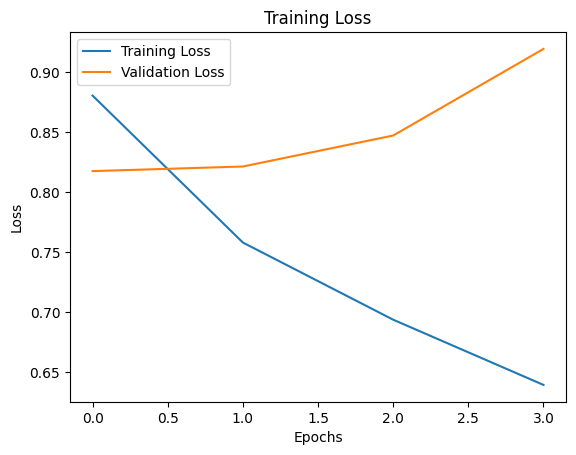

In [31]:
# Plotting Trainig Loss
plt.plot(history.history['loss'], label="Training Loss")
plt.plot(history.history['val_loss'], label="Validation Loss")
plt.legend()
plt.xlabel("Epochs"); plt.ylabel("Loss")
plt.title("Training Loss"); plt.show()

In [32]:
"""Improvement for Bidirectional RNN
"""
from tensorflow.keras.layers import Bidirectional
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import BatchNormalization

vocab_size_1 = 50000
max_len_1 = 150

tokenizer_1 = Tokenizer(num_words=vocab_size_1)
tokenizer_1.fit_on_texts(X_train)

X_train_seq_1 = tokenizer_1.texts_to_sequences(X_train)
X_test_seq_1  = tokenizer_1.texts_to_sequences(X_test)

X_train_pad_1 = pad_sequences(X_train_seq_1, maxlen=max_len_1, padding='post')
X_test_pad_1  = pad_sequences(X_test_seq_1, maxlen=max_len_1, padding='post')



# Bidirectional LSTM Model

model_1 = Sequential([
    Embedding(input_dim=vocab_size_1, output_dim=128, input_length=max_len_1),

    Bidirectional(LSTM(
        128,
        return_sequences=True,
        dropout=0.2
    )),
    BatchNormalization(),
    Dropout(0.3),

    Bidirectional(LSTM(64, dropout=0.2)),
    Dropout(0.3),

    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.4),

    Dense(3, activation='softmax')
])


model_1.compile(
    loss='categorical_crossentropy',
    optimizer=Adam(learning_rate=1e-3),
    metrics=['accuracy']
)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [33]:
# Train

rlrop = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=2,
    min_lr=1e-6
)

history_1 = model_1.fit(
    X_train_pad_1,
    y_train.values,
    batch_size=64,
    epochs=20,
    validation_split=0.1,
    callbacks=[es, rlrop]
)

Epoch 1/20
1692/1692 ━━━━━━━━━━━━━━━━━━━━ 78s 42ms/step - accuracy: 0.4500 - loss: 1.1380 - val_accuracy: 0.6358 - val_loss: 0.8321 - learning_rate: 0.0010
Epoch 2/20
1692/1692 ━━━━━━━━━━━━━━━━━━━━ 72s 43ms/step - accuracy: 0.6572 - loss: 0.7944 - val_accuracy: 0.6063 - val_loss: 0.8908 - learning_rate: 0.0010
Epoch 3/20
1692/1692 ━━━━━━━━━━━━━━━━━━━━ 72s 42ms/step - accuracy: 0.6849 - loss: 0.7302 - val_accuracy: 0.6377 - val_loss: 0.8391 - learning_rate: 0.0010
Epoch 4/20
1692/1692 ━━━━━━━━━━━━━━━━━━━━ 73s 43ms/step - accuracy: 0.7107 - loss: 0.6604 - val_accuracy: 0.6326 - val_loss: 0.8938 - learning_rate: 3.0000e-04


In [34]:
# Predict probabilities
probs_1 = model_1.predict(X_test_pad_1)

# Tune thresholds for each label
best_thresh = []
for i in range(3):
    best_t = 0.5
    best_f1 = 0
    for t in np.arange(0.1, 0.9, 0.02):
        preds_t = (probs_1[:, i] > t).astype(int)
        f1 = f1_score(y_test.iloc[:, i], preds_t)
        if f1 > best_f1:
            best_f1 = f1
            best_t = t
    best_thresh.append(best_t)

best_thresh = np.array(best_thresh)
print(best_thresh)


1611/1611 ━━━━━━━━━━━━━━━━━━━━ 17s 10ms/step
[0.3  0.24 0.36]


In [35]:
pred_1 = (probs_1 > best_thresh.reshape(1, -1)).astype(int)

print("Bidirectional  F1 :", f1_score(y_test, pred_1, average='macro')*100)
print(classification_report(y_test, pred_1))

Bidirectional  F1 : 63.07971752572953
              precision    recall  f1-score   support

           0       0.67      0.69      0.68     17690
           1       0.44      0.70      0.54     11564
           2       0.56      0.84      0.67     22292

   micro avg       0.56      0.76      0.64     51546
   macro avg       0.56      0.74      0.63     51546
weighted avg       0.57      0.76      0.65     51546
 samples avg       0.60      0.76      0.65     51546



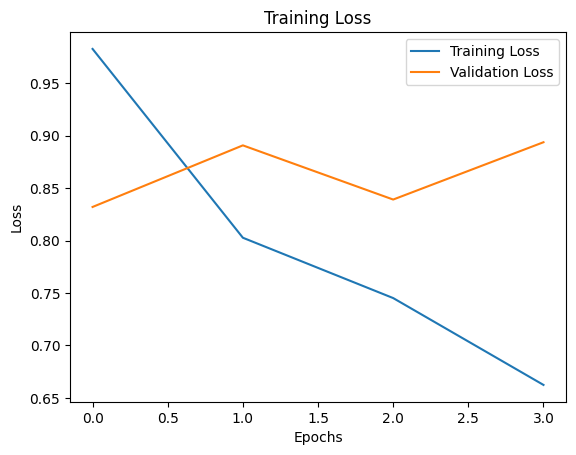

In [36]:
# Plotting Trainig Loss
plt.plot(history_1.history['loss'], label="Training Loss")
plt.plot(history_1.history['val_loss'], label="Validation Loss")
plt.legend()
plt.xlabel("Epochs"); plt.ylabel("Loss")
plt.title("Training Loss"); plt.show()

In [40]:
import shap
import numpy as np
from collections import defaultdict

# 1. Define your 3 classes explicitly
three_class_labels = ['Positive', 'Negative','Neutral']

def shap_top_words_per_label_3class(model, X_data, tokenizer, n_samples=10, top_k=5):
    """
    Compute SHAP values for a 3-class model and extract top words per class.
    """
    # Map token indices back to words
    index_to_word = {v: k for k, v in tokenizer.word_index.items()}

    # Subset for speed
    X_subset = X_data[:n_samples]

    # Wrapper to force inputs to Integer (crucial for Embedding layers)
    def model_predict(x):
        return model.predict(x.astype(int))

    # Initialize SHAP Explainer
    explainer = shap.Explainer(model_predict, X_subset)
    shap_values = explainer(X_subset)

    # Handle Shape Variations (SHAP output format varies by version)
    vals = shap_values.values
    if isinstance(vals, list):
        vals = np.stack(vals, axis=-1)

    # It should now be (n_samples, seq_len, 3)
    num_labels = vals.shape[-1]

    results = {}

    # Iterate over the 3 classes
    for label_idx in range(num_labels):

        word_impact_sum = defaultdict(float)
        word_counts = defaultdict(int)

        for sample_i in range(n_samples):
            for seq_j in range(X_subset.shape[1]):

                token_id = int(X_subset[sample_i, seq_j])

                if token_id == 0: continue # Skip padding

                # Get SHAP value for this specific class (0, 1, or 2)
                shap_val = vals[sample_i, seq_j, label_idx]
                word = index_to_word.get(token_id, "[UNK]")

                # Accumulate
                word_impact_sum[word] += shap_val
                word_counts[word] += 1

        # Calculate average
        avg_word_scores = {}
        for word, total_shap in word_impact_sum.items():
            avg_word_scores[word] = total_shap / word_counts[word]

        # Sort top words for this class
        sorted_words = sorted(avg_word_scores.items(), key=lambda x: x[1], reverse=True)[:top_k]
        results[label_idx] = sorted_words

    return results

# --- Run Analysis ---
# Make sure to pass your 3-class model and the corresponding X data
shap_results = shap_top_words_per_label_3class(
    model,        # Your 3-class model
    X_test_pad,   # Your data
    tokenizer,
    n_samples=20, # Low number for speed
    top_k=5
)

# --- Print Results ---
for idx, words in shap_results.items():
    label_name = three_class_labels[idx] if idx < len(three_class_labels) else f"Class {idx}"
    print(f"\nTop words driving '{label_name}':")
    for word, score in words:
        print(f"  {word}: {score:.4f}")

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
9/9 ━━━━━━━━

PermutationExplainer explainer:  15%|█▌        | 3/20 [00:00<?, ?it/s]

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


PermutationExplainer explainer:  25%|██▌       | 5/20 [00:14<00:21,  1.41s/it]

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


...

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


PermutationExplainer explainer: 100%|██████████| 20/20 [00:53<00:00,  2.55s/it]

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 


PermutationExplainer explainer: 21it [00:57,  3.18s/it]


Top words driving 'Positive':
  thanks: 0.5592
  love: 0.4609
  amazing: 0.4366
  hope: 0.3502
  haha: 0.3380

Top words driving 'Negative':
  terrible: 0.3185
  sad: 0.3007
  hate: 0.2306
  cruel: 0.1199
  doesnt: 0.1099

Top words driving 'Neutral':
  powder: 0.1707
  always: 0.0915
  unexpected: 0.0915
  grandparents: 0.0796
  plugs: 0.0789


In [38]:
print(f"Accuracy RNN: {accuracy_score(y_test, predRNN)*100}")
print(f"Accuracy BiRNN: {accuracy_score(y_test, pred_1)*100}")

Accuracy RNN: 54.08179102161177
Accuracy BiRNN: 45.26248399487836


In [39]:
print(f"Precision RNN: {precision_score(y_test, predRNN, average='macro')*100}")
print(f"Recall RNN: {recall_score(y_test, predRNN, average='macro')*100}")
print(f"Precision BiRNN: {precision_score(y_test, pred_1, average='macro')*100}")
print(f"Recall BiRNN: {recall_score(y_test, pred_1, average='macro')*100}")

Precision RNN: 67.72960499524203
Recall RNN: 51.48113048499729
Precision BiRNN: 55.731196587604735
Recall BiRNN: 74.27774124200548
